In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtk


In [2]:
money_fmt = mtk.FuncFormatter(lambda x, _: f"${x:,.0f}")
print('Ready')

Ready


In [3]:
df = pd.read_excel('finance_transactions_dataset.xlsx')

print(df.shape)
print(df.columns.tolist())

(1000, 14)
['Transaction_ID', 'Company', 'Sector', 'Department', 'Transaction_Type', 'Category', 'Amount', 'Tax_Rate', 'Tax_Amount', 'Net_Amount', 'Currency', 'Transaction_Date', 'Approval_Status', 'Analyst']


In [4]:
df.head()

,Transaction_ID,Company,Sector,Department,Transaction_Type,Category,Amount,Tax_Rate,Tax_Amount,Net_Amount,Currency,Transaction_Date,Approval_Status,Analyst
0,TXN1001,GreenEnergy,Energy,Marketing,Loan Repayment,NaN,104037.35,0.09,9363.36,94673.99,USD,2022-05-24,Pending,Analyst_B
1,TXN1002,LogiTrans,Logistics,IT,Loan Repayment,NaN,431438.64,0.10,43143.86,388294.78,USD,2023-08-04,Pending,Analyst_D
2,TXN1003,EduGroup,Education,Sales,Investment,NaN,494837.13,0.18,89070.68,405766.45,GBP,2023-08-05,Rejected,Analyst_B
3,TXN1004,HealthPlus,Healthcare,Sales,Revenue,NaN,59347.25,0.09,5341.25,54006.00,USD,2024-11-01,Pending,Analyst_A
4,TXN1005,EduGroup,Education,Finance,Loan Repayment,NaN,132500.40,0.15,19875.06,112625.34,GBP,2021-09-16,Approved,Analyst_C


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    1000 non-null   object 
 1   Company           956 non-null    object 
 2   Sector            1000 non-null   object 
 3   Department        946 non-null    object 
 4   Transaction_Type  1000 non-null   object 
 5   Category          211 non-null    object 
 6   Amount            961 non-null    float64
 7   Tax_Rate          1000 non-null   float64
 8   Tax_Amount        1000 non-null   float64
 9   Net_Amount        960 non-null    float64
 10  Currency          1000 non-null   object 
 11  Transaction_Date  952 non-null    object 
 12  Approval_Status   961 non-null    object 
 13  Analyst           955 non-null    object 
dtypes: float64(4), object(10)
memory usage: 109.5+ KB


In [6]:
df.describe().round(2)

,Amount,Tax_Rate,Tax_Amount,Net_Amount
count,961.00,1000.00,1000.00,960.00
mean,248309.09,0.18,44196.90,203859.56
std,145329.13,0.07,33447.57,120727.44
min,5132.61,0.05,355.38,3644.15
25%,115322.10,0.12,16896.31,94843.24
50%,250121.30,0.18,35780.50,200693.33
75%,375654.46,0.24,66364.00,308532.69
max,499771.64,0.30,148757.97,454365.87


In [7]:
df.isnull().sum()

Transaction_ID        0
Company              44
Sector                0
Department           54
Transaction_Type      0
Category            789
Amount               39
Tax_Rate              0
Tax_Amount            0
Net_Amount           40
Currency              0
Transaction_Date     48
Approval_Status      39
Analyst              45
dtype: int64

In [8]:
df.dropna(subset=['Amount', 'Net_Amount', 'Currency', 'Transaction_Date', 'Approval_Status'],inplace=True)
print('Rows remaining:', len(df))

Rows remaining: 845


In [9]:
df['Company'] = df['Company'].fillna('UnKnown')
df['Department'] = df['Department'].fillna('UnKnown')
df['Analyst'] = df['Analyst'].fillna('UnKnown')
df['Category'] = df['Category'].fillna('N/A')

#re-run your previous code

In [10]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], errors='coerce')
df.dropna(subset=['Transaction_Date'],inplace=True)

df['Year'] = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.to_period('M').astype(str)

print('Sample dates:')
print(df[['Transaction_Date', 'Year', 'Month']].head(3))

Sample dates:
  Transaction_Date  Year    Month
0       2022-05-24  2022  2022-05
1       2023-08-04  2023  2023-08
2       2023-08-05  2023  2023-08


In [11]:
df.drop_duplicates(inplace=True)
print('Final row count:', len(df))

Final row count: 845


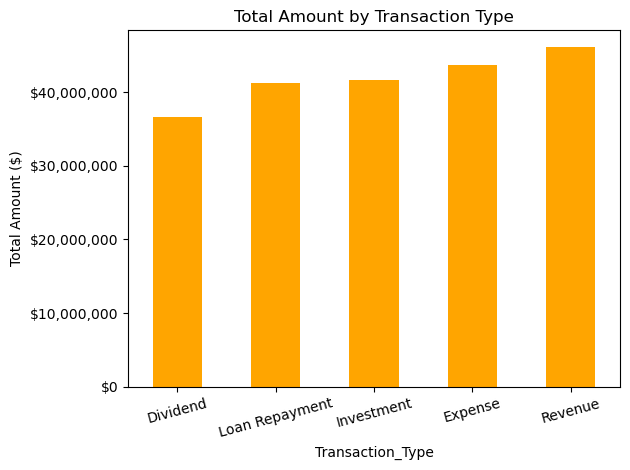

In [12]:
df.groupby('Transaction_Type')['Amount'].sum().sort_values().plot(
    kind='bar',color='orange'
)
plt.title('Total Amount by Transaction Type')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=15)
plt.gca().yaxis.set_major_formatter(money_fmt)
plt.tight_layout()
plt.show()

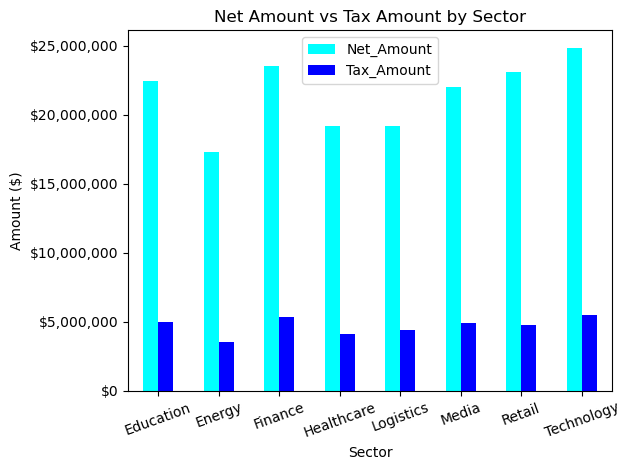

In [13]:
df.groupby('Sector')[['Net_Amount','Tax_Amount']].sum().plot(
    kind='bar',color=['cyan', 'blue']
)
plt.title('Net Amount vs Tax Amount by Sector')
plt.ylabel('Amount ($)')
plt.xticks(rotation=20)
plt.gca().yaxis.set_major_formatter(money_fmt)
plt.tight_layout()
plt.show()

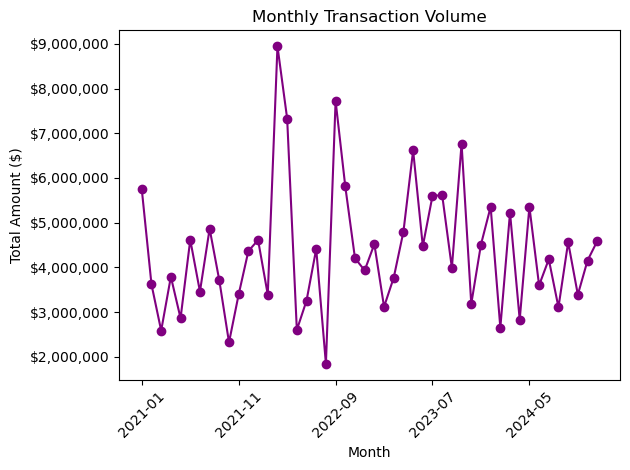

In [14]:
df.groupby('Month')['Amount'].sum().plot(
    kind='line', marker='o', color='purple'
)
plt.title('Monthly Transaction Volume')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(money_fmt)
plt.tight_layout()
plt.show()

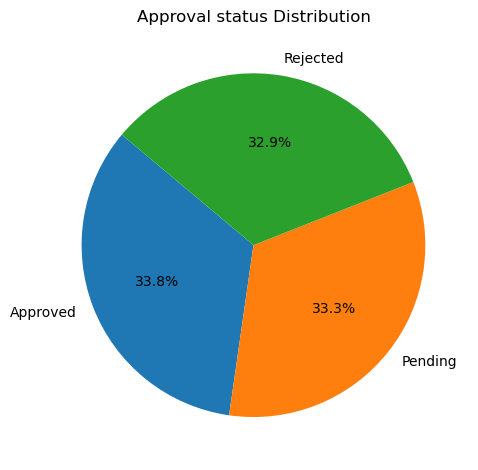

In [15]:
df['Approval_Status'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',startangle=140
)
plt.title('Approval status Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

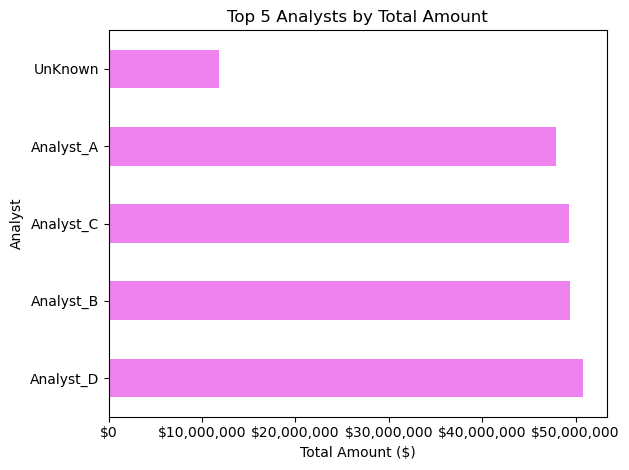

In [16]:
df.groupby('Analyst')['Amount'].sum().nlargest(5).plot(
    kind='barh',color='violet'
)
plt.title('Top 5 Analysts by Total Amount')
plt.xlabel('Total Amount ($)')
plt.gca().xaxis.set_major_formatter(money_fmt)
plt.tight_layout()
plt.show()

In [17]:
print('=' * 46)
print('          FINANCE DATASET SUMMARY')
print('=' * 46)
print(f"Transactions:       {len(df):,}")
print(f"Total Amount:       ${df['Amount'].sum():,.0f}")
print(f"Total Tax Paid:     ${df['Tax_Amount'].sum():,.0f}")
print(f"Total Net Amount:   ${df['Net_Amount'].sum():,.0f}")
print(f"Avg Tax Rate:       {df['Tax_Rate'].mean()*100:.1f}%")
print(f"Approval Rate:      {(df['Approval_Status']=='Approved').mean()*100:.1f}%")
print(f"Top Sector:         {df.groupby('Sector')['Amount'].sum().idxmax()}")
print(f"Top Analyst:        {df.groupby('Analyst')['Amount'].sum().idxmax()}")
print('=' * 46)

          FINANCE DATASET SUMMARY
Transactions:       845
Total Amount:       $209,284,457
Total Tax Paid:     $37,622,745
Total Net Amount:   $171,661,713
Avg Tax Rate:       17.9%
Approval Rate:      33.8%
Top Sector:         Technology
Top Analyst:        Analyst_D


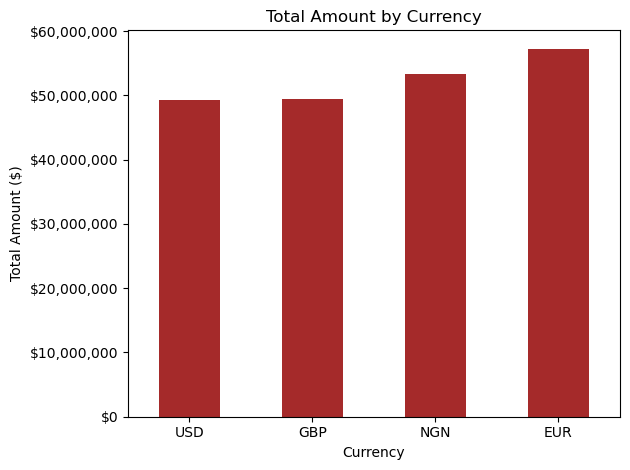

In [18]:
#Exercise
df.groupby('Currency')['Amount'].sum().sort_values().plot(
    kind='bar',color='brown'
)
plt.title('Total Amount by Currency')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(money_fmt)
plt.tight_layout()
plt.show()

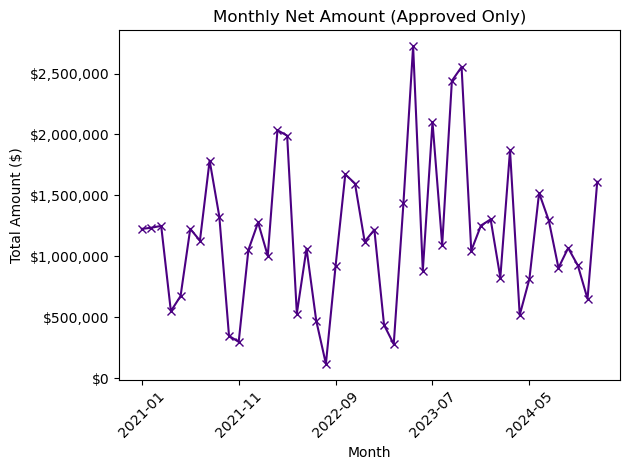

In [19]:
approved = df[df['Approval_Status']=='Approved']

approved.groupby('Month')['Net_Amount'].sum().plot(
    kind='line', marker='x', color='indigo'
)
plt.title('Monthly Net Amount (Approved Only)')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(money_fmt)
plt.tight_layout()
plt.show()

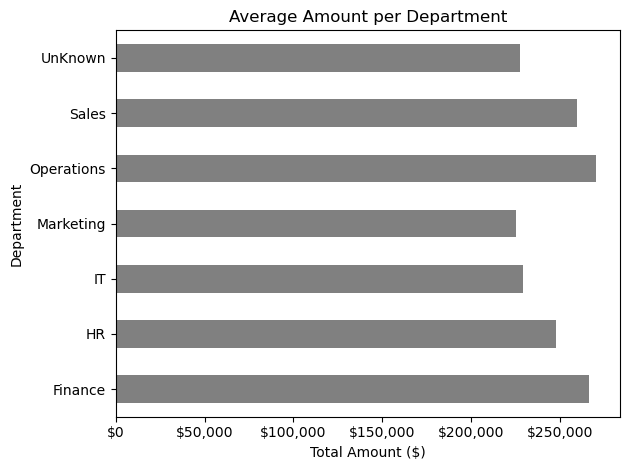

In [20]:
df.groupby('Department')['Amount'].mean().plot(
    kind='barh',color='grey'
)
plt.title('Average Amount per Department')
plt.xlabel('Total Amount ($)')
plt.gca().xaxis.set_major_formatter(money_fmt)
plt.tight_layout()
plt.show()

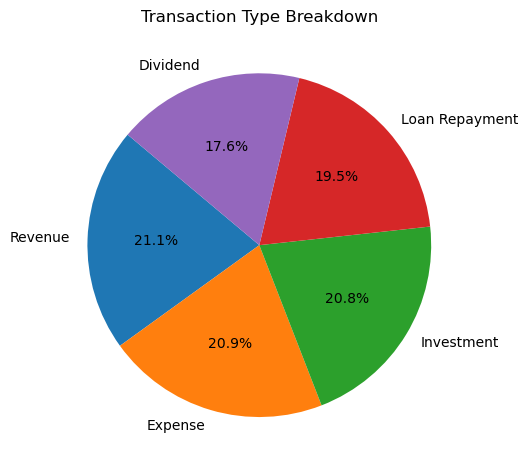

In [21]:
df['Transaction_Type'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',startangle=140
)
plt.title('Transaction Type Breakdown')
plt.ylabel('')
plt.tight_layout()
plt.show()

ValueError: Invalid color 

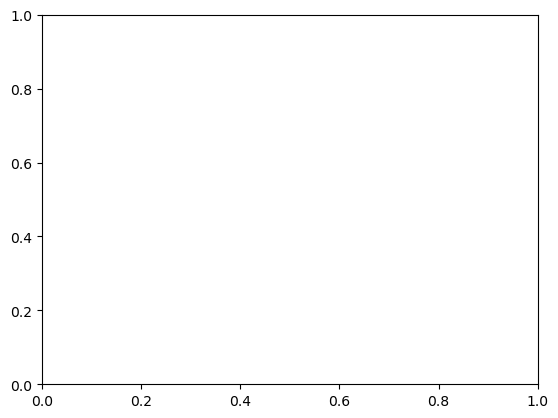

In [22]:
expenses = df[df['Transaction_Type']=='Expense']

expenses.groupby('Category')['Amount'].sum().sort_values().plot(
    kind='bar',color=''
)
plt.title('Total Amount by Currency')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(money_fmt)
plt.tight_layout()
plt.show()